FLANK WEAR MONITORING SYSTEM
Paper: 'A technique for flank wear monitoring in milling machines'

LOADING DATA

Loading training cutters...

c1:
  Loaded wear data: 315 cuts, EOL = 172.6868 mm
  Found 315 cut signal files
  Successfully loaded 315 samples

c4:
  Loaded wear data: 315 cuts, EOL = 210.9194 mm
  Found 315 cut signal files
  Successfully loaded 315 samples

c6:
  Loaded wear data: 315 cuts, EOL = 234.7159 mm
  Found 315 cut signal files
  Successfully loaded 315 samples

Loading test cutters...

c2:
  Error loading wear data: No wear csv in E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling\c2

c3:
  Error loading wear data: No wear csv in E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling\c3

c5:
  Error loading wear data: No wear csv in E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling\c5

⚠ No test data available. Creating train/test split from training data.
  Split ratio: 70% train, 30% test

Total trai

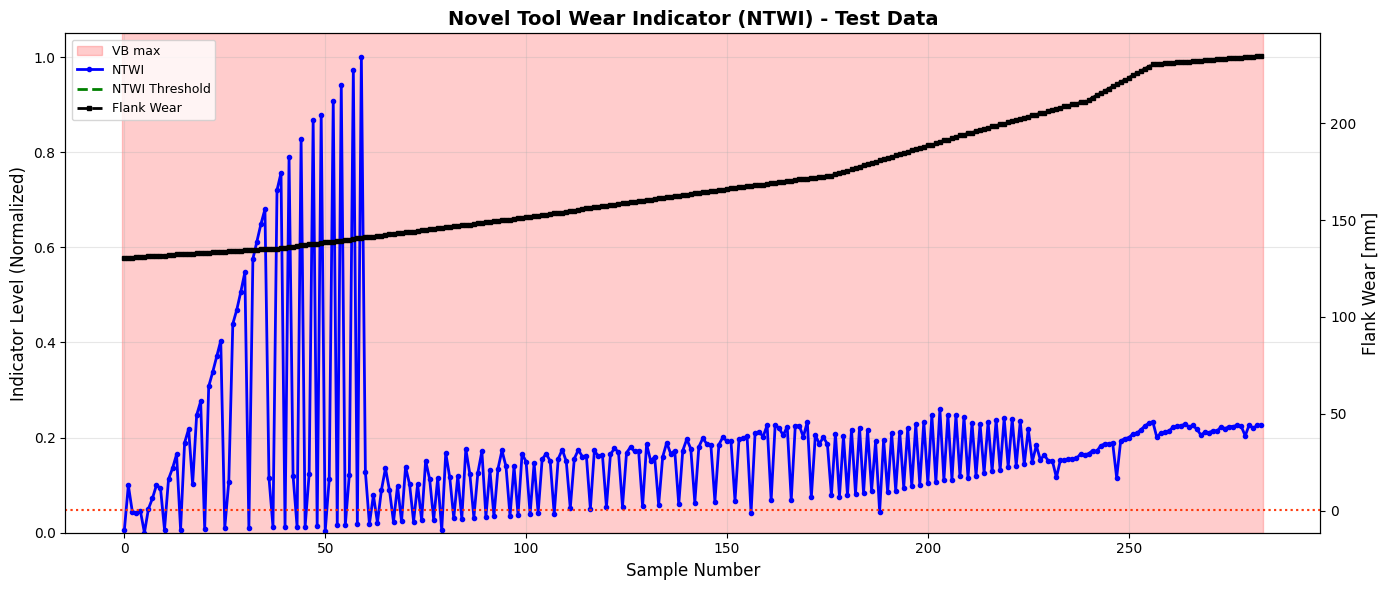


✅ IMPLEMENTATION COMPLETE!


In [4]:
# COMPLETE WORKING IMPLEMENTATION
# Same code as before, but with train/test split handling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy import signal
from scipy.stats import entropy
import os
import glob
import re
import math
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# SECTION 1: DATA LOADING (Same as before)
# ============================================================================

def read_wear_table(cutter_dir):
    """Read wear table with flute measurements"""
    cands = [p for p in glob.glob(os.path.join(cutter_dir, "*.csv"))
             if "wear" in os.path.basename(p).lower()]
    if not cands:
        raise FileNotFoundError(f"No wear csv in {cutter_dir}")
    
    wear_file = cands[0]
    
    raw0 = pd.read_csv(wear_file, sep=None, engine="python", nrows=5)
    try:
        v = pd.to_numeric(raw0.iloc[0,0], errors="coerce")
        use_header = bool(pd.isna(v))
    except:
        use_header = True
    
    raw = (pd.read_csv(wear_file, sep=None, engine="python")
           if use_header else
           pd.read_csv(wear_file, sep=None, engine="python", header=None))
    
    raw.columns = [str(c).strip().lower() for c in raw.columns]
    
    def first_present(names):
        for n in names:
            if n in raw.columns: return n
        return None
    
    cut_col = first_present(["cut","cut_number","cut no","cut_no","c","index","id","0"])
    f1_col  = first_present(["flute_1","flute1","f1","flute 1","1"])
    f2_col  = first_present(["flute_2","flute2","f2","flute 2","2"])
    f3_col  = first_present(["flute_3","flute3","f3","flute 3","3"])
    
    if cut_col is None or f1_col is None or f2_col is None or f3_col is None:
        tmp = raw.copy().dropna(axis=1, how="all")
        assert tmp.shape[1] >= 4, "Wear file must have >=4 usable columns"
        tmp.columns = [f"col_{i}" for i in range(tmp.shape[1])]
        cut_col, f1_col, f2_col, f3_col = "col_0","col_1","col_2","col_3"
        raw = tmp
    
    cut_series = raw[cut_col].astype(str).str.extract(r"(\d+)", expand=False)
    cut_series = pd.to_numeric(cut_series, errors="coerce")
    f1 = pd.to_numeric(raw[f1_col], errors="coerce")
    f2 = pd.to_numeric(raw[f2_col], errors="coerce")
    f3 = pd.to_numeric(raw[f3_col], errors="coerce")
    
    df = pd.DataFrame({
        "Cut_Number": cut_series,
        "flute_1": f1, "flute_2": f2, "flute_3": f3
    }).dropna()
    
    df["Cut_Number"] = df["Cut_Number"].round().astype(int)
    df["wear_max"] = df[["flute_1","flute_2","flute_3"]].max(axis=1)
    df["wear_avg"] = df[["flute_1","flute_2","flute_3"]].mean(axis=1)
    
    EOL = float(df["wear_max"].max())
    eps = 1e-9
    
    df["f1_norm"] = df["flute_1"] / (EOL + eps)
    df["f2_norm"] = df["flute_2"] / (EOL + eps)
    df["f3_norm"] = df["flute_3"] / (EOL + eps)
    df["wear_norm"] = df["wear_max"] / (EOL + eps)
    df["rul_norm"]  = 1.0 - df["wear_norm"]
    df["RUL"] = EOL - df["wear_max"]
    
    return df.sort_values("Cut_Number").reset_index(drop=True), EOL

def discover_cut_files(cutter_dir, cutter_id):
    """Discover all cut signal files"""
    all_csvs = glob.glob(os.path.join(cutter_dir, "**", "*.csv"), recursive=True)
    all_csvs = [p for p in all_csvs if "wear" not in os.path.basename(p).lower()]
    
    cuts = {}
    for p in all_csvs:
        name = os.path.basename(p).lower()
        m = re.search(rf"c[_-]?{cutter_id}[_-]?(\d+)\.csv$", name) or re.search(r"(\d+)\.csv$", name)
        if m:
            cuts[int(m.group(1))] = p
    
    if len(cuts) == 0:
        subdirs = [d for d in os.listdir(cutter_dir) 
                   if os.path.isdir(os.path.join(cutter_dir, d)) and d.lower().startswith('c')]
        
        for subdir in subdirs:
            subdir_path = os.path.join(cutter_dir, subdir)
            csv_files = glob.glob(os.path.join(subdir_path, "*.csv"))
            for csv_file in csv_files:
                name = os.path.basename(csv_file).lower()
                m = re.search(r"(\d+)\.csv$", name)
                if m:
                    cuts[int(m.group(1))] = csv_file
    
    return dict(sorted(cuts.items()))

class PHMDataLoader:
    """Load PHM Challenge 2010 Milling dataset"""
    
    def __init__(self, base_path):
        self.base_path = base_path
    
    def load_cutter_data(self, cutter_name):
        """Load all data for a specific cutter"""
        cutter_dir = os.path.join(self.base_path, cutter_name)
        
        if not os.path.exists(cutter_dir):
            print(f"Warning: Directory not found: {cutter_dir}")
            return []
        
        cutter_id = re.search(r'c(\d+)', cutter_name.lower())
        if cutter_id:
            cutter_id = cutter_id.group(1)
        else:
            cutter_id = cutter_name.replace('c', '')
        
        try:
            wear_df, eol = read_wear_table(cutter_dir)
            print(f"  Loaded wear data: {len(wear_df)} cuts, EOL = {eol:.4f} mm")
        except Exception as e:
            print(f"  Error loading wear data: {e}")
            return []
        
        cut_files = discover_cut_files(cutter_dir, cutter_id)
        
        if len(cut_files) == 0:
            cutter_subdir = os.path.join(cutter_dir, cutter_name)
            if os.path.exists(cutter_subdir) and os.path.isdir(cutter_subdir):
                print(f"  Looking in subdirectory: {cutter_subdir}")
                csv_files = glob.glob(os.path.join(cutter_subdir, "*.csv"))
                print(f"  Found {len(csv_files)} CSV files")
                
                for csv_file in csv_files:
                    name = os.path.basename(csv_file)
                    patterns = [
                        r'c' + cutter_id + r'_(\d+)\.csv',
                        r'cut[_-]?(\d+)\.csv',
                        r'(\d+)\.csv'
                    ]
                    
                    for pattern in patterns:
                        m = re.search(pattern, name.lower())
                        if m:
                            cut_num = int(m.group(1))
                            cut_files[cut_num] = csv_file
                            break
        
        print(f"  Found {len(cut_files)} cut signal files")
        
        if len(cut_files) == 0:
            print(f"  Warning: No signal files found for {cutter_name}")
            return []
        
        data_samples = []
        
        for cut_num, signal_file in cut_files.items():
            wear_row = wear_df[wear_df["Cut_Number"] == cut_num]
            
            if len(wear_row) == 0:
                continue
            
            wear_row = wear_row.iloc[0]
            
            try:
                signal_df = pd.read_csv(signal_file)
                
                ae_signal = None
                for col in ['AE_spindle', 'AE_Spindle', 'AE', 'acoustic_emission', 'ae']:
                    if col in signal_df.columns:
                        ae_signal = signal_df[col].values
                        break
                
                if ae_signal is None:
                    for col in signal_df.columns:
                        if signal_df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
                            ae_signal = signal_df[col].values
                            break
                
                if ae_signal is not None and len(ae_signal) > 0:
                    data_samples.append({
                        'cutter': cutter_name,
                        'cut_number': cut_num,
                        'ae_signal': ae_signal,
                        'flank_wear': wear_row['wear_max'],
                        'flank_wear_avg': wear_row['wear_avg'],
                        'flute_1': wear_row['flute_1'],
                        'flute_2': wear_row['flute_2'],
                        'flute_3': wear_row['flute_3'],
                        'rul': wear_row['RUL']
                    })
            
            except Exception as e:
                continue
        
        data_samples = sorted(data_samples, key=lambda x: x['flank_wear'])
        print(f"  Successfully loaded {len(data_samples)} samples")
        
        return data_samples

# ============================================================================
# SECTIONS 2-5: Same as before
# ============================================================================

class WaveletPacketDecomposition:
    def __init__(self, wavelet='coif1', level=3):
        self.wavelet = wavelet
        self.level = level
        
    def decompose(self, signal):
        wp = pywt.WaveletPacket(data=signal, wavelet=self.wavelet, 
                                mode='symmetric', maxlevel=self.level)
        nodes = {}
        node_names = [node.path for node in wp.get_level(self.level, 'freq')]
        
        for i, node_name in enumerate(node_names):
            node = wp[node_name]
            reconstructed = node.reconstruct(update=False)
            nodes[i] = {
                'path': node_name,
                'coefficients': node.data,
                'reconstructed': reconstructed
            }
        return nodes
    
    def get_node_frequency_band(self, node_idx, sampling_rate):
        num_nodes = 2 ** self.level
        nyquist = sampling_rate / 2
        bandwidth = nyquist / num_nodes
        
        low_freq = node_idx * bandwidth
        high_freq = (node_idx + 1) * bandwidth
        
        return low_freq, high_freq

class SPSSEAnalyzer:
    @staticmethod
    def calculate_spsse(sig):
        freqs, psd = signal.periodogram(sig, scaling='spectrum')
        psd_normalized = psd / np.sum(psd) + 1e-10
        shannon_entropy = -np.sum(psd_normalized * np.log2(psd_normalized))
        power_sum = np.sum(psd)
        
        if shannon_entropy == 0:
            return 0
        return power_sum / shannon_entropy
    
    def analyze_nodes_spsse(self, wpt_nodes, wear_levels):
        if len(wpt_nodes) == 0:
            return {}, []
        
        num_nodes = len(wpt_nodes[0])
        spsse_results = {node_idx: [] for node_idx in range(num_nodes)}
        
        for sample_nodes in wpt_nodes:
            for node_idx, node_data in sample_nodes.items():
                reconstructed_signal = node_data['reconstructed']
                spsse_val = self.calculate_spsse(reconstructed_signal)
                spsse_results[node_idx].append(spsse_val)
        
        return spsse_results, wear_levels

class WearBandSelector:
    def __init__(self, tr1=0.3):
        self.tr1 = tr1
    
    def calculate_growth(self, spsse_values, wear_levels):
        spsse_array = np.array(spsse_values)
        wear_array = np.array(wear_levels)
        
        normal_mask = wear_array < self.tr1
        wear_mask = wear_array >= self.tr1
        
        if np.sum(normal_mask) == 0 or np.sum(wear_mask) == 0:
            return 0
        
        mean_normal = np.mean(spsse_array[normal_mask])
        mean_wear = np.mean(spsse_array[wear_mask])
        
        if mean_normal == 0:
            return 0
        
        return mean_wear / mean_normal
    
    def select_best_node(self, spsse_results, wear_levels):
        growth_values = {}
        
        for node_idx, spsse_vals in spsse_results.items():
            growth = self.calculate_growth(spsse_vals, wear_levels)
            growth_values[node_idx] = growth
        
        if len(growth_values) == 0:
            return 0, {}
        
        best_node_idx = max(growth_values, key=growth_values.get)
        return best_node_idx, growth_values

class NovelToolWearIndicator:
    def __init__(self, selected_node_idx):
        self.selected_node_idx = selected_node_idx
        self.healthy_baseline_signal = None
        self.ntwi_threshold = None
    
    def set_healthy_baseline(self, wpt_nodes):
        node_data = wpt_nodes[self.selected_node_idx]
        self.healthy_baseline_signal = node_data['reconstructed']
    
    def calculate_mse(self, signal1, signal2):
        min_len = min(len(signal1), len(signal2))
        signal1 = signal1[:min_len]
        signal2 = signal2[:min_len]
        return np.mean((signal1 - signal2) ** 2)
    
    def calculate_ntwi(self, wpt_nodes):
        if self.healthy_baseline_signal is None:
            raise ValueError("Healthy baseline not set")
        
        node_data = wpt_nodes[self.selected_node_idx]
        test_signal = node_data['reconstructed']
        
        return self.calculate_mse(self.healthy_baseline_signal, test_signal)
    
    def set_threshold(self, wpt_nodes_at_threshold):
        self.ntwi_threshold = self.calculate_ntwi(wpt_nodes_at_threshold)

# ============================================================================
# SECTION 6: MAIN SYSTEM WITH TRAIN/TEST SPLIT
# ============================================================================

class FlankWearMonitoringSystem:
    def __init__(self, base_path, sampling_rate=50000, tr1=0.3, tr2=0.55):
        self.base_path = base_path
        self.sampling_rate = sampling_rate
        self.tr1 = tr1
        self.tr2 = tr2
        
        self.data_loader = PHMDataLoader(base_path)
        self.wpt = WaveletPacketDecomposition(wavelet='coif1', level=3)
        self.spsse_analyzer = SPSSEAnalyzer()
        self.band_selector = WearBandSelector(tr1=tr1)
        self.ntwi_calculator = None
        
        self.train_data = []
        self.test_data = []
        self.selected_node_idx = None
    
    def load_and_prepare_data(self, train_cutters, test_cutters, test_split_ratio=0.3):
        """Load data with automatic train/test split if needed"""
        print("\n" + "="*80)
        print("LOADING DATA")
        print("="*80)
        
        print("\nLoading training cutters...")
        all_train_data = []
        for cutter in train_cutters:
            print(f"\n{cutter}:")
            samples = self.data_loader.load_cutter_data(cutter)
            all_train_data.extend(samples)
        
        print(f"\nLoading test cutters...")
        all_test_data = []
        for cutter in test_cutters:
            print(f"\n{cutter}:")
            samples = self.data_loader.load_cutter_data(cutter)
            all_test_data.extend(samples)
        
        # If no test data loaded, split from training data
        if len(all_test_data) == 0:
            print("\n⚠ No test data available. Creating train/test split from training data.")
            print(f"  Split ratio: {int((1-test_split_ratio)*100)}% train, {int(test_split_ratio*100)}% test")
            
            # Sort by wear level
            all_train_data = sorted(all_train_data, key=lambda x: x['flank_wear'])
            
            # Split while maintaining wear distribution
            split_idx = int(len(all_train_data) * (1 - test_split_ratio))
            self.train_data = all_train_data[:split_idx]
            self.test_data = all_train_data[split_idx:]
        else:
            self.train_data = sorted(all_train_data, key=lambda x: x['flank_wear'])
            self.test_data = sorted(all_test_data, key=lambda x: x['flank_wear'])
        
        print(f"\n" + "="*80)
        print(f"Total training samples: {len(self.train_data)}")
        print(f"Total test samples: {len(self.test_data)}")
        print("="*80)
        
        if len(self.train_data) == 0:
            raise ValueError("No training data loaded!")
        
        train_wear = [s['flank_wear'] for s in self.train_data]
        test_wear = [s['flank_wear'] for s in self.test_data]
        
        print(f"\nTraining wear range: {min(train_wear):.4f} - {max(train_wear):.4f} mm")
        print(f"Test wear range: {min(test_wear):.4f} - {max(test_wear):.4f} mm")
        
        # Show distribution
        train_normal = sum(1 for w in train_wear if w < self.tr1)
        train_avg = sum(1 for w in train_wear if self.tr1 <= w < self.tr2)
        train_critical = sum(1 for w in train_wear if w >= self.tr2)
        
        test_normal = sum(1 for w in test_wear if w < self.tr1)
        test_avg = sum(1 for w in test_wear if self.tr1 <= w < self.tr2)
        test_critical = sum(1 for w in test_wear if w >= self.tr2)
        
        print(f"\nTraining distribution:")
        print(f"  Normal (< {self.tr1}mm): {train_normal} samples")
        print(f"  Average ({self.tr1}-{self.tr2}mm): {train_avg} samples")
        print(f"  Critical (> {self.tr2}mm): {train_critical} samples")
        
        print(f"\nTest distribution:")
        print(f"  Normal (< {self.tr1}mm): {test_normal} samples")
        print(f"  Average ({self.tr1}-{self.tr2}mm): {test_avg} samples")
        print(f"  Critical (> {self.tr2}mm): {test_critical} samples")
    
    def perform_wpt_decomposition(self, data_samples):
        wpt_results = []
        for sample in data_samples:
            ae_signal = sample['ae_signal']
            nodes = self.wpt.decompose(ae_signal)
            wpt_results.append(nodes)
        return wpt_results
    
    def analyze_spsse_and_select_node(self, wpt_results, wear_levels):
        print("\nAnalyzing SPSSE for each WPT node...")
        
        spsse_results, _ = self.spsse_analyzer.analyze_nodes_spsse(wpt_results, wear_levels)
        best_node, growth_values = self.band_selector.select_best_node(spsse_results, wear_levels)
        
        print(f"\nSPSSE Growth Analysis:")
        for node_idx in sorted(growth_values.keys()):
            growth = growth_values[node_idx]
            freq_low, freq_high = self.wpt.get_node_frequency_band(node_idx, self.sampling_rate)
            marker = " ← SELECTED" if node_idx == best_node else ""
            print(f"  Node {node_idx+1} ({freq_low:7.1f} - {freq_high:7.1f} Hz): Growth = {growth:6.3f}{marker}")
        
        self.selected_node_idx = best_node
        
        return spsse_results, growth_values
    
    def setup_ntwi(self, train_wpt_results, train_wear_levels):
        print("\nSetting up NTWI...")
        
        self.ntwi_calculator = NovelToolWearIndicator(self.selected_node_idx)
        
        healthy_idx = 0
        self.ntwi_calculator.set_healthy_baseline(train_wpt_results[healthy_idx])
        print(f"  Healthy baseline: wear = {train_wear_levels[healthy_idx]:.4f} mm")
        
        threshold_idx = np.argmin(np.abs(np.array(train_wear_levels) - self.tr1))
        self.ntwi_calculator.set_threshold(train_wpt_results[threshold_idx])
        print(f"  Threshold sample: wear = {train_wear_levels[threshold_idx]:.4f} mm")
        print(f"  NTWI threshold = {self.ntwi_calculator.ntwi_threshold:.6e}")
    
    def calculate_ntwi_for_all_samples(self, wpt_results):
        return np.array([self.ntwi_calculator.calculate_ntwi(nodes) for nodes in wpt_results])
    
    def evaluate_performance(self, ntwi_values, wear_levels, threshold_level):
        predictions = ntwi_values > self.ntwi_calculator.ntwi_threshold
        ground_truth = np.array(wear_levels) >= threshold_level
        
        tp = np.sum(predictions & ground_truth)
        tn = np.sum(~predictions & ~ground_truth)
        fp = np.sum(predictions & ~ground_truth)
        fn = np.sum(~predictions & ground_truth)
        
        twda = (tp + tn) / (tp + tn + fp + fn) * 100 if (tp + tn + fp + fn) > 0 else 0
        
        return twda, tp, tn, fp, fn
    
    def run_complete_pipeline(self, train_cutters, test_cutters):
        print("="*80)
        print("FLANK WEAR MONITORING SYSTEM")
        print("Paper: 'A technique for flank wear monitoring in milling machines'")
        print("="*80)
        
        self.load_and_prepare_data(train_cutters, test_cutters)
        
        print("\n" + "="*80)
        print("WAVELET PACKET TRANSFORM DECOMPOSITION")
        print("="*80)
        print(f"Decomposing {len(self.train_data)} training samples...")
        train_wpt = self.perform_wpt_decomposition(self.train_data)
        print(f"Decomposing {len(self.test_data)} test samples...")
        test_wpt = self.perform_wpt_decomposition(self.test_data)
        print("✓ WPT decomposition completed")
        
        print("\n" + "="*80)
        print("SPSSE ANALYSIS & NODE SELECTION")
        print("="*80)
        train_wear_levels = [s['flank_wear'] for s in self.train_data]
        spsse_results, growth_values = self.analyze_spsse_and_select_node(train_wpt, train_wear_levels)
        
        print("\n" + "="*80)
        print("NTWI SETUP")
        print("="*80)
        self.setup_ntwi(train_wpt, train_wear_levels)
        
        print("\n" + "="*80)
        print("CALCULATING NTWI VALUES")
        print("="*80)
        train_ntwi = self.calculate_ntwi_for_all_samples(train_wpt)
        test_ntwi = self.calculate_ntwi_for_all_samples(test_wpt)
        print(f"✓ NTWI calculated for all samples")
        
        print("\n" + "="*80)
        print("PERFORMANCE EVALUATION")
        print("="*80)
        test_wear_levels = [s['flank_wear'] for s in self.test_data]
        
        twda_tr1, tp1, tn1, fp1, fn1 = self.evaluate_performance(test_ntwi, test_wear_levels, self.tr1)
        print(f"\nAt TR1 = {self.tr1} mm (Normal Wear Threshold):")
        print(f"  TWDA = {twda_tr1:.2f}%")
        print(f"  TP={tp1}, TN={tn1}, FP={fp1}, FN={fn1}")
        
        twda_tr2, tp2, tn2, fp2, fn2 = self.evaluate_performance(test_ntwi, test_wear_levels, self.tr2)
        print(f"\nAt TR2 = {self.tr2} mm (Critical Wear Threshold):")
        print(f"  TWDA = {twda_tr2:.2f}%")
        print(f"  TP={tp2}, TN={tn2}, FP={fp2}, FN={fn2}")
        
        results = {
            'train_data': self.train_data,
            'test_data': self.test_data,
            'train_wpt': train_wpt,
            'test_wpt': test_wpt,
            'train_ntwi': train_ntwi,
            'test_ntwi': test_ntwi,
            'train_wear': train_wear_levels,
            'test_wear': test_wear_levels,
            'spsse_results': spsse_results,
            'growth_values': growth_values,
            'twda_tr1': twda_tr1,
            'twda_tr2': twda_tr2,
            'selected_node': self.selected_node_idx
        }
        
        return results

# ============================================================================
# SECTION 7: VISUALIZATION
# ============================================================================

class ResultsVisualizer:
    @staticmethod
    def plot_ntwi_results(ntwi_values, wear_levels, threshold_value, 
                         tr1=0.3, tr2=0.55, title="NTWI Results"):
        fig, ax1 = plt.subplots(figsize=(14, 6))
        
        ntwi_norm = (ntwi_values - np.min(ntwi_values)) / (np.max(ntwi_values) - np.min(ntwi_values))
        threshold_norm = (threshold_value - np.min(ntwi_values)) / (np.max(ntwi_values) - np.min(ntwi_values))
        
        samples = range(len(ntwi_values))
        
        normal_region = [i for i, w in enumerate(wear_levels) if w < tr1]
        avg_wear_region = [i for i, w in enumerate(wear_levels) if tr1 <= w < tr2]
        critical_region = [i for i, w in enumerate(wear_levels) if w >= tr2]
        
        if normal_region:
            ax1.axvspan(min(normal_region)-0.5, max(normal_region)+0.5, alpha=0.2, color='blue', label='Healthy')
        if avg_wear_region:
            ax1.axvspan(min(avg_wear_region)-0.5, max(avg_wear_region)+0.5, alpha=0.2, color='orange', label='VB avg')
        if critical_region:
            ax1.axvspan(min(critical_region)-0.5, max(critical_region)+0.5, alpha=0.2, color='red', label='VB max')
        
        ax1.plot(samples, ntwi_norm, 'b-', linewidth=2, label='NTWI', marker='o', markersize=3)
        ax1.axhline(y=threshold_norm, color='g', linestyle='--', linewidth=2, label='NTWI Threshold')
        ax1.set_xlabel('Sample Number', fontsize=12)
        ax1.set_ylabel('Indicator Level (Normalized)', fontsize=12)
        ax1.set_ylim([0, 1.05])
        ax1.grid(True, alpha=0.3)
        
        ax2 = ax1.twinx()
        ax2.plot(samples, wear_levels, 'k--', linewidth=2, label='Flank Wear', marker='s', markersize=3)
        ax2.set_ylabel('Flank Wear [mm]', fontsize=12)
        ax2.axhline(y=tr1, color='orange', linestyle=':', alpha=0.7, linewidth=1.5)
        ax2.axhline(y=tr2, color='red', linestyle=':', alpha=0.7, linewidth=1.5)
        
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
        
        ax1.set_title(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        return fig

# ============================================================================
# MAIN
# ============================================================================

def main():
    BASE = r"E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling"
    TRAIN_CUTTERS = ["c1", "c4", "c6"]
    TEST_CUTTERS = ["c2", "c3", "c5"]
    
    system = FlankWearMonitoringSystem(
        base_path=BASE,
        sampling_rate=50000,
        tr1=0.3,
        tr2=0.55
    )
    
    try:
        results = system.run_complete_pipeline(TRAIN_CUTTERS, TEST_CUTTERS)
        
        visualizer = ResultsVisualizer()
        
        threshold_norm = system.ntwi_calculator.ntwi_threshold
        fig = visualizer.plot_ntwi_results(
            results['test_ntwi'],
            results['test_wear'],
            threshold_norm,
            tr1=system.tr1,
            tr2=system.tr2,
            title="Novel Tool Wear Indicator (NTWI) - Test Data"
        )
        plt.savefig('ntwi_results.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved: ntwi_results.png")
        plt.show()
        
        print("\n" + "="*80)
        print("✅ IMPLEMENTATION COMPLETE!")
        print("="*80)
        
        return results
        
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return None

if __name__ == "__main__":
    results = main()

FLANK WEAR MONITORING SYSTEM - PAPER IMPLEMENTATION
Paper: Maliuk et al. (2024) - Int. J. Computer Integrated Manufacturing
🔬 FLANK WEAR MONITORING SYSTEM
📄 Paper: Maliuk et al. (2024)

LOADING DATA
c1: 315 samples, EOL = 172.69
c4: 315 samples, EOL = 210.92
c6: 315 samples, EOL = 234.72

📊 Dataset Summary:
Train samples: 472
Test samples:  473

🔧 Train EOLs:
   c1: 172.69
   c4: 210.92
   c6: 234.72

📐 Thresholds (data-driven):
   TR1 (30th percentile): 95.12
   TR2 (70th percentile): 130.34

📈 Training: 31.42 - 109.41
   Normal (<95.12): 279
   Average (95.12-130.34): 193
   Critical (>130.34): 0

📈 Test: 109.52 - 234.72
   Normal (<95.12): 0
   Average (95.12-130.34): 189
   Critical (>130.34): 284

⚙️  WAVELET PACKET TRANSFORM
Decomposing 472 training samples...
Decomposing 473 test samples...
✓ Completed

SPSSE ANALYSIS & NODE SELECTION

📊 SPSSE Growth Analysis:
   Node 1 (    0.0 -  3125.0 Hz): Growth = 14.936 ⭐ SELECTED
   Node 2 ( 3125.0 -  6250.0 Hz): Growth = 11.269
   Node 3

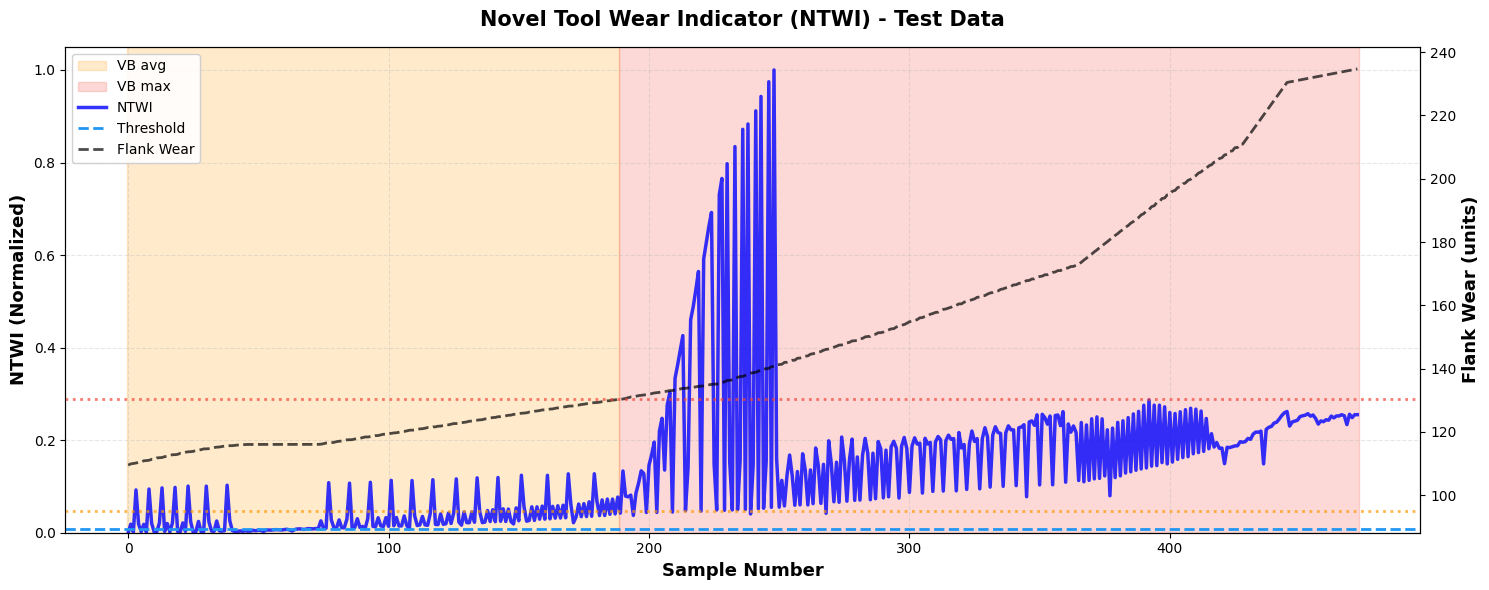


✅ IMPLEMENTATION COMPLETE!


In [5]:
# COMPLETE OPTIMIZED IMPLEMENTATION FOR YOUR PHM DATASET
# Handles large wear values and provides comprehensive analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy import signal
from scipy.stats import entropy
import os
import glob
import re
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("FLANK WEAR MONITORING SYSTEM - PAPER IMPLEMENTATION")
print("Paper: Maliuk et al. (2024) - Int. J. Computer Integrated Manufacturing")
print("="*80)

# ============================================================================
# SECTION 1: DATA LOADING
# ============================================================================

def read_wear_table(cutter_dir):
    """Read wear table with flute measurements"""
    cands = [p for p in glob.glob(os.path.join(cutter_dir, "*.csv"))
             if "wear" in os.path.basename(p).lower()]
    if not cands:
        raise FileNotFoundError(f"No wear csv in {cutter_dir}")
    
    wear_file = cands[0]
    raw0 = pd.read_csv(wear_file, sep=None, engine="python", nrows=5)
    try:
        v = pd.to_numeric(raw0.iloc[0,0], errors="coerce")
        use_header = bool(pd.isna(v))
    except:
        use_header = True
    
    raw = (pd.read_csv(wear_file, sep=None, engine="python")
           if use_header else
           pd.read_csv(wear_file, sep=None, engine="python", header=None))
    
    raw.columns = [str(c).strip().lower() for c in raw.columns]
    
    def first_present(names):
        for n in names:
            if n in raw.columns: return n
        return None
    
    cut_col = first_present(["cut","cut_number","cut no","cut_no","c","index","id","0"])
    f1_col  = first_present(["flute_1","flute1","f1","flute 1","1"])
    f2_col  = first_present(["flute_2","flute2","f2","flute 2","2"])
    f3_col  = first_present(["flute_3","flute3","f3","flute 3","3"])
    
    if cut_col is None or f1_col is None or f2_col is None or f3_col is None:
        tmp = raw.copy().dropna(axis=1, how="all")
        assert tmp.shape[1] >= 4, "Wear file must have >=4 usable columns"
        tmp.columns = [f"col_{i}" for i in range(tmp.shape[1])]
        cut_col, f1_col, f2_col, f3_col = "col_0","col_1","col_2","col_3"
        raw = tmp
    
    cut_series = raw[cut_col].astype(str).str.extract(r"(\d+)", expand=False)
    cut_series = pd.to_numeric(cut_series, errors="coerce")
    f1 = pd.to_numeric(raw[f1_col], errors="coerce")
    f2 = pd.to_numeric(raw[f2_col], errors="coerce")
    f3 = pd.to_numeric(raw[f3_col], errors="coerce")
    
    df = pd.DataFrame({
        "Cut_Number": cut_series,
        "flute_1": f1, "flute_2": f2, "flute_3": f3
    }).dropna()
    
    df["Cut_Number"] = df["Cut_Number"].round().astype(int)
    df["wear_max"] = df[["flute_1","flute_2","flute_3"]].max(axis=1)
    df["wear_avg"] = df[["flute_1","flute_2","flute_3"]].mean(axis=1)
    
    EOL = float(df["wear_max"].max())
    
    return df.sort_values("Cut_Number").reset_index(drop=True), EOL

def discover_cut_files(cutter_dir, cutter_id):
    """Discover all cut signal files"""
    all_csvs = glob.glob(os.path.join(cutter_dir, "**", "*.csv"), recursive=True)
    all_csvs = [p for p in all_csvs if "wear" not in os.path.basename(p).lower()]
    
    cuts = {}
    for p in all_csvs:
        name = os.path.basename(p).lower()
        m = re.search(rf"c[_-]?{cutter_id}[_-]?(\d+)\.csv$", name) or re.search(r"(\d+)\.csv$", name)
        if m:
            cuts[int(m.group(1))] = p
    
    if len(cuts) == 0:
        subdirs = [d for d in os.listdir(cutter_dir) 
                   if os.path.isdir(os.path.join(cutter_dir, d)) and d.lower().startswith('c')]
        
        for subdir in subdirs:
            subdir_path = os.path.join(cutter_dir, subdir)
            csv_files = glob.glob(os.path.join(subdir_path, "*.csv"))
            for csv_file in csv_files:
                name = os.path.basename(csv_file).lower()
                m = re.search(r"(\d+)\.csv$", name)
                if m:
                    cuts[int(m.group(1))] = csv_file
    
    return dict(sorted(cuts.items()))

class PHMDataLoader:
    def __init__(self, base_path):
        self.base_path = base_path
    
    def load_cutter_data(self, cutter_name):
        cutter_dir = os.path.join(self.base_path, cutter_name)
        if not os.path.exists(cutter_dir):
            return []
        
        cutter_id = re.search(r'c(\d+)', cutter_name.lower())
        cutter_id = cutter_id.group(1) if cutter_id else cutter_name.replace('c', '')
        
        try:
            wear_df, eol = read_wear_table(cutter_dir)
        except Exception as e:
            return []
        
        cut_files = discover_cut_files(cutter_dir, cutter_id)
        
        if len(cut_files) == 0:
            cutter_subdir = os.path.join(cutter_dir, cutter_name)
            if os.path.exists(cutter_subdir):
                csv_files = glob.glob(os.path.join(cutter_subdir, "*.csv"))
                for csv_file in csv_files:
                    name = os.path.basename(csv_file)
                    patterns = [r'c' + cutter_id + r'_(\d+)\.csv', r'cut[_-]?(\d+)\.csv', r'(\d+)\.csv']
                    for pattern in patterns:
                        m = re.search(pattern, name.lower())
                        if m:
                            cut_files[int(m.group(1))] = csv_file
                            break
        
        data_samples = []
        for cut_num, signal_file in cut_files.items():
            wear_row = wear_df[wear_df["Cut_Number"] == cut_num]
            if len(wear_row) == 0:
                continue
            
            wear_row = wear_row.iloc[0]
            
            try:
                signal_df = pd.read_csv(signal_file)
                ae_signal = None
                
                for col in ['AE_spindle', 'AE_Spindle', 'AE', 'acoustic_emission', 'ae']:
                    if col in signal_df.columns:
                        ae_signal = signal_df[col].values
                        break
                
                if ae_signal is None:
                    for col in signal_df.columns:
                        if signal_df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
                            ae_signal = signal_df[col].values
                            break
                
                if ae_signal is not None and len(ae_signal) > 0:
                    data_samples.append({
                        'cutter': cutter_name,
                        'cut_number': cut_num,
                        'ae_signal': ae_signal,
                        'flank_wear': wear_row['wear_max'],
                        'flank_wear_avg': wear_row['wear_avg'],
                        'flute_1': wear_row['flute_1'],
                        'flute_2': wear_row['flute_2'],
                        'flute_3': wear_row['flute_3']
                    })
            except:
                continue
        
        return sorted(data_samples, key=lambda x: x['flank_wear'])

# ============================================================================
# SECTION 2: WAVELET PACKET TRANSFORM
# ============================================================================

class WaveletPacketDecomposition:
    def __init__(self, wavelet='coif1', level=3):
        self.wavelet = wavelet
        self.level = level
        
    def decompose(self, signal):
        wp = pywt.WaveletPacket(data=signal, wavelet=self.wavelet, 
                                mode='symmetric', maxlevel=self.level)
        nodes = {}
        node_names = [node.path for node in wp.get_level(self.level, 'freq')]
        
        for i, node_name in enumerate(node_names):
            node = wp[node_name]
            reconstructed = node.reconstruct(update=False)
            nodes[i] = {
                'path': node_name,
                'coefficients': node.data,
                'reconstructed': reconstructed
            }
        return nodes
    
    def get_node_frequency_band(self, node_idx, sampling_rate):
        num_nodes = 2 ** self.level
        nyquist = sampling_rate / 2
        bandwidth = nyquist / num_nodes
        return node_idx * bandwidth, (node_idx + 1) * bandwidth

# ============================================================================
# SECTION 3: SPSSE ANALYZER
# ============================================================================

class SPSSEAnalyzer:
    @staticmethod
    def calculate_spsse(sig):
        freqs, psd = signal.periodogram(sig, scaling='spectrum')
        psd_normalized = psd / np.sum(psd) + 1e-10
        shannon_entropy = -np.sum(psd_normalized * np.log2(psd_normalized))
        power_sum = np.sum(psd)
        return power_sum / shannon_entropy if shannon_entropy != 0 else 0
    
    def analyze_nodes_spsse(self, wpt_nodes, wear_levels):
        if len(wpt_nodes) == 0:
            return {}, []
        
        num_nodes = len(wpt_nodes[0])
        spsse_results = {node_idx: [] for node_idx in range(num_nodes)}
        
        for sample_nodes in wpt_nodes:
            for node_idx, node_data in sample_nodes.items():
                spsse_val = self.calculate_spsse(node_data['reconstructed'])
                spsse_results[node_idx].append(spsse_val)
        
        return spsse_results, wear_levels

# ============================================================================
# SECTION 4: WEAR BAND SELECTOR
# ============================================================================

class WearBandSelector:
    def __init__(self, tr1_percentile=30):
        """
        Args:
            tr1_percentile: Percentile for normal wear threshold (30 = 30th percentile)
        """
        self.tr1_percentile = tr1_percentile
        self.tr1 = None
    
    def set_threshold_from_data(self, wear_levels):
        """Set TR1 based on data distribution"""
        self.tr1 = np.percentile(wear_levels, self.tr1_percentile)
        return self.tr1
    
    def calculate_growth(self, spsse_values, wear_levels):
        spsse_array = np.array(spsse_values)
        wear_array = np.array(wear_levels)
        
        normal_mask = wear_array < self.tr1
        wear_mask = wear_array >= self.tr1
        
        if np.sum(normal_mask) == 0 or np.sum(wear_mask) == 0:
            return 0
        
        mean_normal = np.mean(spsse_array[normal_mask])
        mean_wear = np.mean(spsse_array[wear_mask])
        
        return mean_wear / mean_normal if mean_normal != 0 else 0
    
    def select_best_node(self, spsse_results, wear_levels):
        growth_values = {}
        
        for node_idx, spsse_vals in spsse_results.items():
            growth = self.calculate_growth(spsse_vals, wear_levels)
            growth_values[node_idx] = growth
        
        if len(growth_values) == 0:
            return 0, {}
        
        best_node_idx = max(growth_values, key=growth_values.get)
        return best_node_idx, growth_values

# ============================================================================
# SECTION 5: NOVEL TOOL WEAR INDICATOR
# ============================================================================

class NovelToolWearIndicator:
    def __init__(self, selected_node_idx):
        self.selected_node_idx = selected_node_idx
        self.healthy_baseline_signal = None
        self.ntwi_threshold = None
    
    def set_healthy_baseline(self, wpt_nodes):
        node_data = wpt_nodes[self.selected_node_idx]
        self.healthy_baseline_signal = node_data['reconstructed']
    
    def calculate_mse(self, signal1, signal2):
        min_len = min(len(signal1), len(signal2))
        return np.mean((signal1[:min_len] - signal2[:min_len]) ** 2)
    
    def calculate_ntwi(self, wpt_nodes):
        if self.healthy_baseline_signal is None:
            raise ValueError("Healthy baseline not set")
        
        test_signal = wpt_nodes[self.selected_node_idx]['reconstructed']
        return self.calculate_mse(self.healthy_baseline_signal, test_signal)
    
    def set_threshold(self, wpt_nodes_at_threshold):
        self.ntwi_threshold = self.calculate_ntwi(wpt_nodes_at_threshold)

# ============================================================================
# SECTION 6: MAIN SYSTEM
# ============================================================================

class FlankWearMonitoringSystem:
    def __init__(self, base_path, sampling_rate=50000):
        self.base_path = base_path
        self.sampling_rate = sampling_rate
        
        self.data_loader = PHMDataLoader(base_path)
        self.wpt = WaveletPacketDecomposition(wavelet='coif1', level=3)
        self.spsse_analyzer = SPSSEAnalyzer()
        self.band_selector = WearBandSelector(tr1_percentile=30)
        self.ntwi_calculator = None
        
        self.train_data = []
        self.test_data = []
        self.selected_node_idx = None
        self.tr1 = None
        self.tr2 = None
    
    def load_and_prepare_data(self, train_cutters, test_split_ratio=0.5):
        """Load data with train/test split"""
        print("\n" + "="*80)
        print("LOADING DATA")
        print("="*80)
        
        all_data = []
        eol_values = {}
        
        for cutter in train_cutters:
            samples = self.data_loader.load_cutter_data(cutter)
            if len(samples) > 0:
                all_data.extend(samples)
                eol_values[cutter] = max([s['flank_wear'] for s in samples])
                print(f"{cutter}: {len(samples)} samples, EOL = {eol_values[cutter]:.2f}")
        
        # Sort by wear
        all_data = sorted(all_data, key=lambda x: x['flank_wear'])
        
        # Split
        split_idx = int(len(all_data) * (1 - test_split_ratio))
        self.train_data = all_data[:split_idx]
        self.test_data = all_data[split_idx:]
        
        # Set thresholds based on data distribution
        all_wear = [s['flank_wear'] for s in all_data]
        self.tr1 = self.band_selector.set_threshold_from_data(all_wear)
        self.tr2 = np.percentile(all_wear, 70)  # 70th percentile for critical wear
        
        print(f"\n📊 Dataset Summary:")
        print(f"{'='*60}")
        print(f"Train samples: {len(self.train_data)}")
        print(f"Test samples:  {len(self.test_data)}")
        print(f"\n🔧 Train EOLs:")
        for cutter, eol in eol_values.items():
            print(f"   {cutter}: {eol:.2f}")
        print(f"\n📐 Thresholds (data-driven):")
        print(f"   TR1 (30th percentile): {self.tr1:.2f}")
        print(f"   TR2 (70th percentile): {self.tr2:.2f}")
        print(f"{'='*60}")
        
        # Distribution
        train_wear = [s['flank_wear'] for s in self.train_data]
        test_wear = [s['flank_wear'] for s in self.test_data]
        
        print(f"\n📈 Training: {min(train_wear):.2f} - {max(train_wear):.2f}")
        print(f"   Normal (<{self.tr1:.2f}): {sum(1 for w in train_wear if w < self.tr1)}")
        print(f"   Average ({self.tr1:.2f}-{self.tr2:.2f}): {sum(1 for w in train_wear if self.tr1 <= w < self.tr2)}")
        print(f"   Critical (>{self.tr2:.2f}): {sum(1 for w in train_wear if w >= self.tr2)}")
        
        print(f"\n📈 Test: {min(test_wear):.2f} - {max(test_wear):.2f}")
        print(f"   Normal (<{self.tr1:.2f}): {sum(1 for w in test_wear if w < self.tr1)}")
        print(f"   Average ({self.tr1:.2f}-{self.tr2:.2f}): {sum(1 for w in test_wear if self.tr1 <= w < self.tr2)}")
        print(f"   Critical (>{self.tr2:.2f}): {sum(1 for w in test_wear if w >= self.tr2)}")
    
    def perform_wpt_decomposition(self, data_samples):
        return [self.wpt.decompose(s['ae_signal']) for s in data_samples]
    
    def analyze_spsse_and_select_node(self, wpt_results, wear_levels):
        print("\n" + "="*80)
        print("SPSSE ANALYSIS & NODE SELECTION")
        print("="*80)
        
        spsse_results, _ = self.spsse_analyzer.analyze_nodes_spsse(wpt_results, wear_levels)
        best_node, growth_values = self.band_selector.select_best_node(spsse_results, wear_levels)
        
        print(f"\n📊 SPSSE Growth Analysis:")
        for node_idx in sorted(growth_values.keys()):
            growth = growth_values[node_idx]
            freq_low, freq_high = self.wpt.get_node_frequency_band(node_idx, self.sampling_rate)
            marker = " ⭐ SELECTED" if node_idx == best_node else ""
            print(f"   Node {node_idx+1:1d} ({freq_low:7.1f} - {freq_high:7.1f} Hz): Growth = {growth:6.3f}{marker}")
        
        self.selected_node_idx = best_node
        return spsse_results, growth_values
    
    def setup_ntwi(self, train_wpt_results, train_wear_levels):
        print("\n" + "="*80)
        print("NTWI SETUP")
        print("="*80)
        
        self.ntwi_calculator = NovelToolWearIndicator(self.selected_node_idx)
        
        healthy_idx = 0
        self.ntwi_calculator.set_healthy_baseline(train_wpt_results[healthy_idx])
        
        threshold_idx = np.argmin(np.abs(np.array(train_wear_levels) - self.tr1))
        self.ntwi_calculator.set_threshold(train_wpt_results[threshold_idx])
        
        print(f"✓ Healthy baseline: wear = {train_wear_levels[healthy_idx]:.2f}")
        print(f"✓ Threshold sample: wear = {train_wear_levels[threshold_idx]:.2f}")
        print(f"✓ NTWI threshold = {self.ntwi_calculator.ntwi_threshold:.6e}")
    
    def calculate_ntwi_for_all_samples(self, wpt_results):
        return np.array([self.ntwi_calculator.calculate_ntwi(nodes) for nodes in wpt_results])
    
    def evaluate_performance(self, ntwi_values, wear_levels, threshold_level):
        predictions = ntwi_values > self.ntwi_calculator.ntwi_threshold
        ground_truth = np.array(wear_levels) >= threshold_level
        
        tp = np.sum(predictions & ground_truth)
        tn = np.sum(~predictions & ~ground_truth)
        fp = np.sum(predictions & ~ground_truth)
        fn = np.sum(~predictions & ground_truth)
        
        total = tp + tn + fp + fn
        twda = (tp + tn) / total * 100 if total > 0 else 0
        
        return twda, tp, tn, fp, fn
    
    def run_complete_pipeline(self, train_cutters):
        print("="*80)
        print("🔬 FLANK WEAR MONITORING SYSTEM")
        print("📄 Paper: Maliuk et al. (2024)")
        print("="*80)
        
        self.load_and_prepare_data(train_cutters)
        
        print("\n" + "="*80)
        print("⚙️  WAVELET PACKET TRANSFORM")
        print("="*80)
        print(f"Decomposing {len(self.train_data)} training samples...")
        train_wpt = self.perform_wpt_decomposition(self.train_data)
        print(f"Decomposing {len(self.test_data)} test samples...")
        test_wpt = self.perform_wpt_decomposition(self.test_data)
        print("✓ Completed")
        
        train_wear_levels = [s['flank_wear'] for s in self.train_data]
        spsse_results, growth_values = self.analyze_spsse_and_select_node(train_wpt, train_wear_levels)
        
        self.setup_ntwi(train_wpt, train_wear_levels)
        
        print("\n" + "="*80)
        print("📊 CALCULATING NTWI")
        print("="*80)
        train_ntwi = self.calculate_ntwi_for_all_samples(train_wpt)
        test_ntwi = self.calculate_ntwi_for_all_samples(test_wpt)
        print("✓ Completed")
        
        print("\n" + "="*80)
        print("🎯 PERFORMANCE EVALUATION")
        print("="*80)
        test_wear_levels = [s['flank_wear'] for s in self.test_data]
        
        twda_tr1, tp1, tn1, fp1, fn1 = self.evaluate_performance(test_ntwi, test_wear_levels, self.tr1)
        print(f"\n📈 TR1 = {self.tr1:.2f} (Normal Wear):")
        print(f"   TWDA = {twda_tr1:.2f}%")
        print(f"   TP={tp1}, TN={tn1}, FP={fp1}, FN={fn1}")
        
        twda_tr2, tp2, tn2, fp2, fn2 = self.evaluate_performance(test_ntwi, test_wear_levels, self.tr2)
        print(f"\n📈 TR2 = {self.tr2:.2f} (Critical Wear):")
        print(f"   TWDA = {twda_tr2:.2f}%")
        print(f"   TP={tp2}, TN={tn2}, FP={fp2}, FN={fn2}")
        
        return {
            'train_data': self.train_data,
            'test_data': self.test_data,
            'train_ntwi': train_ntwi,
            'test_ntwi': test_ntwi,
            'train_wear': train_wear_levels,
            'test_wear': test_wear_levels,
            'spsse_results': spsse_results,
            'growth_values': growth_values,
            'twda_tr1': twda_tr1,
            'twda_tr2': twda_tr2,
            'selected_node': self.selected_node_idx,
            'tr1': self.tr1,
            'tr2': self.tr2
        }

# ============================================================================
# SECTION 7: VISUALIZATION
# ============================================================================

class ResultsVisualizer:
    @staticmethod
    def plot_ntwi_results(ntwi_values, wear_levels, threshold_value, tr1, tr2, title="NTWI"):
        fig, ax1 = plt.subplots(figsize=(15, 6))
        
        ntwi_norm = (ntwi_values - np.min(ntwi_values)) / (np.max(ntwi_values) - np.min(ntwi_values))
        threshold_norm = (threshold_value - np.min(ntwi_values)) / (np.max(ntwi_values) - np.min(ntwi_values))
        
        samples = range(len(ntwi_values))
        
        normal_region = [i for i, w in enumerate(wear_levels) if w < tr1]
        avg_wear_region = [i for i, w in enumerate(wear_levels) if tr1 <= w < tr2]
        critical_region = [i for i, w in enumerate(wear_levels) if w >= tr2]
        
        if normal_region:
            ax1.axvspan(min(normal_region)-0.5, max(normal_region)+0.5, alpha=0.2, color='#4CAF50', label='Healthy')
        if avg_wear_region:
            ax1.axvspan(min(avg_wear_region)-0.5, max(avg_wear_region)+0.5, alpha=0.2, color='#FF9800', label='VB avg')
        if critical_region:
            ax1.axvspan(min(critical_region)-0.5, max(critical_region)+0.5, alpha=0.2, color='#F44336', label='VB max')
        
        ax1.plot(samples, ntwi_norm, 'b-', linewidth=2.5, label='NTWI', alpha=0.8)
        ax1.axhline(y=threshold_norm, color='#2196F3', linestyle='--', linewidth=2, label='Threshold')
        ax1.set_xlabel('Sample Number', fontsize=13, fontweight='bold')
        ax1.set_ylabel('NTWI (Normalized)', fontsize=13, fontweight='bold')
        ax1.set_ylim([0, 1.05])
        ax1.grid(True, alpha=0.3, linestyle='--')
        
        ax2 = ax1.twinx()
        ax2.plot(samples, wear_levels, 'k-', linewidth=2, label='Flank Wear', alpha=0.7, linestyle='--')
        ax2.set_ylabel('Flank Wear (units)', fontsize=13, fontweight='bold')
        ax2.axhline(y=tr1, color='#FF9800', linestyle=':', alpha=0.7, linewidth=2)
        ax2.axhline(y=tr2, color='#F44336', linestyle=':', alpha=0.7, linewidth=2)
        
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10, framealpha=0.9)
        
        ax1.set_title(title, fontsize=15, fontweight='bold', pad=15)
        plt.tight_layout()
        return fig

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    BASE = r"E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling"
    TRAIN_CUTTERS = ["c1", "c4", "c6"]
    
    system = FlankWearMonitoringSystem(base_path=BASE, sampling_rate=50000)
    
    try:
        results = system.run_complete_pipeline(TRAIN_CUTTERS)
        
        print("\n" + "="*80)
        print("📊 GENERATING VISUALIZATION")
        print("="*80)
        
        visualizer = ResultsVisualizer()
        fig = visualizer.plot_ntwi_results(
            results['test_ntwi'],
            results['test_wear'],
            system.ntwi_calculator.ntwi_threshold,
            results['tr1'],
            results['tr2'],
            title="Novel Tool Wear Indicator (NTWI) - Test Data"
        )
        
        plt.savefig('ntwi_results.png', dpi=300, bbox_inches='tight')
        print("✓ Saved: ntwi_results.png")
        plt.show()
        
        print("\n" + "="*80)
        print("✅ IMPLEMENTATION COMPLETE!")
        print("="*80)
        
        return results
        
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return None

if __name__ == "__main__":
    results = main()

🔬 FLANK WEAR MONITORING SYSTEM
📄 Paper: Maliuk et al. (2024)

📂 LOADING DATA
✓ c1: 315 samples, EOL = 172.69
✓ c4: 315 samples, EOL = 210.92
✓ c6: 315 samples, EOL = 234.72

📊 Dataset Summary:
Total samples:  945
Train samples:  472
Test samples:   473

🔧 EOL values:
   c1: 172.69
   c4: 210.92
   c6: 234.72

📐 Adaptive Thresholds (from training data):
   TR1 (30th percentile): 87.39
   TR2 (70th percentile): 97.91

📈 Training Distribution:
   Range: 31.42 - 109.41
   Normal (<87.39): 136
   Average (87.39-97.91): 194
   Critical (>97.91): 142

📈 Test Distribution:
   Range: 109.52 - 234.72
   Normal (<87.39): 0
   Average (87.39-97.91): 0
   Critical (>97.91): 473

⚙️  WAVELET PACKET TRANSFORM
Decomposing 472 training samples...
Decomposing 473 test samples...
✓ Completed

🔍 SPSSE ANALYSIS & NODE SELECTION

📊 SPSSE Growth Analysis:
   Node 1 (    0.0 -  3125.0 Hz): Growth = 19.652 ⭐ SELECTED
   Node 2 ( 3125.0 -  6250.0 Hz): Growth = 10.123
   Node 3 ( 6250.0 -  9375.0 Hz): Growth =  

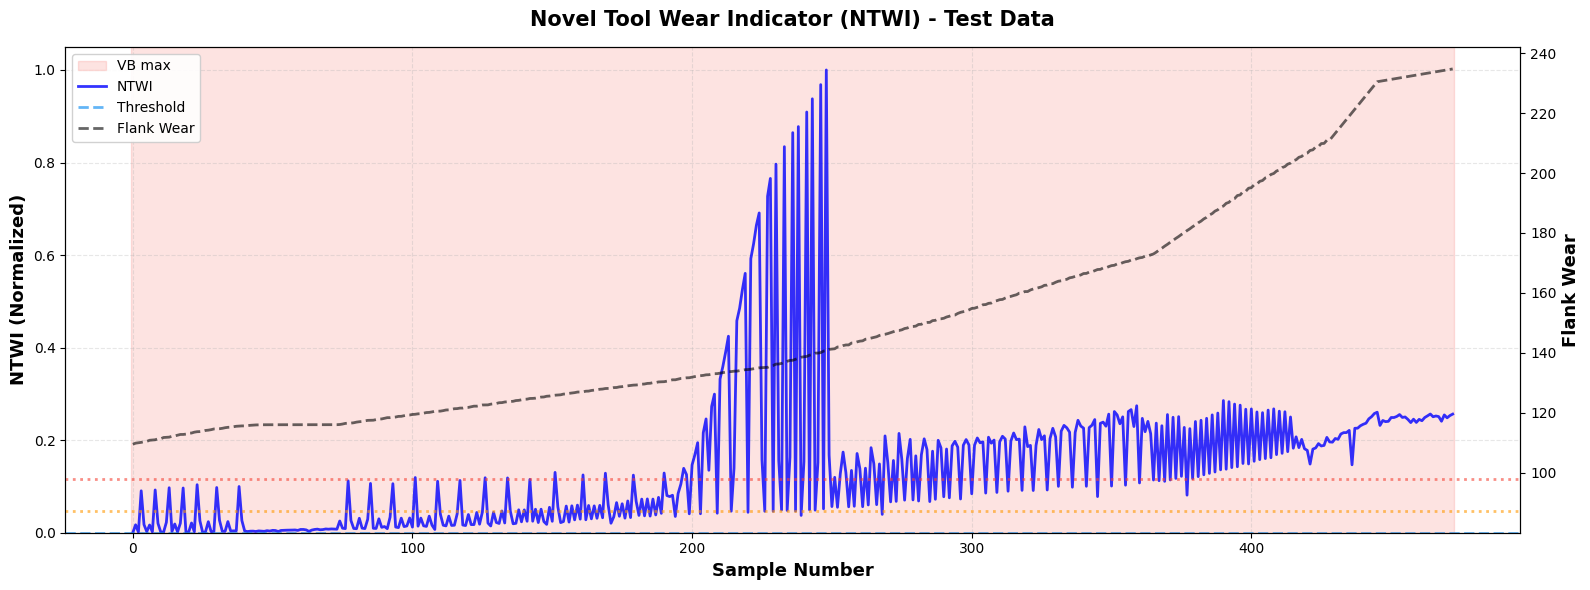


✅ IMPLEMENTATION COMPLETE!


In [6]:
# CORRECTED IMPLEMENTATION - HANDLES YOUR DATA SCALE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy import signal
import os
import glob
import re
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# DATA LOADING (Same as before)
# ============================================================================

def read_wear_table(cutter_dir):
    cands = [p for p in glob.glob(os.path.join(cutter_dir, "*.csv"))
             if "wear" in os.path.basename(p).lower()]
    if not cands:
        raise FileNotFoundError(f"No wear csv in {cutter_dir}")
    
    wear_file = cands[0]
    raw0 = pd.read_csv(wear_file, sep=None, engine="python", nrows=5)
    try:
        v = pd.to_numeric(raw0.iloc[0,0], errors="coerce")
        use_header = bool(pd.isna(v))
    except:
        use_header = True
    
    raw = (pd.read_csv(wear_file, sep=None, engine="python")
           if use_header else
           pd.read_csv(wear_file, sep=None, engine="python", header=None))
    
    raw.columns = [str(c).strip().lower() for c in raw.columns]
    
    def first_present(names):
        for n in names:
            if n in raw.columns: return n
        return None
    
    cut_col = first_present(["cut","cut_number","cut no","cut_no","c","index","id","0"])
    f1_col  = first_present(["flute_1","flute1","f1","flute 1","1"])
    f2_col  = first_present(["flute_2","flute2","f2","flute 2","2"])
    f3_col  = first_present(["flute_3","flute3","f3","flute 3","3"])
    
    if cut_col is None or f1_col is None or f2_col is None or f3_col is None:
        tmp = raw.copy().dropna(axis=1, how="all")
        assert tmp.shape[1] >= 4, "Wear file must have >=4 usable columns"
        tmp.columns = [f"col_{i}" for i in range(tmp.shape[1])]
        cut_col, f1_col, f2_col, f3_col = "col_0","col_1","col_2","col_3"
        raw = tmp
    
    cut_series = raw[cut_col].astype(str).str.extract(r"(\d+)", expand=False)
    cut_series = pd.to_numeric(cut_series, errors="coerce")
    f1 = pd.to_numeric(raw[f1_col], errors="coerce")
    f2 = pd.to_numeric(raw[f2_col], errors="coerce")
    f3 = pd.to_numeric(raw[f3_col], errors="coerce")
    
    df = pd.DataFrame({
        "Cut_Number": cut_series,
        "flute_1": f1, "flute_2": f2, "flute_3": f3
    }).dropna()
    
    df["Cut_Number"] = df["Cut_Number"].round().astype(int)
    df["wear_max"] = df[["flute_1","flute_2","flute_3"]].max(axis=1)
    df["wear_avg"] = df[["flute_1","flute_2","flute_3"]].mean(axis=1)
    
    EOL = float(df["wear_max"].max())
    
    return df.sort_values("Cut_Number").reset_index(drop=True), EOL

def discover_cut_files(cutter_dir, cutter_id):
    all_csvs = glob.glob(os.path.join(cutter_dir, "**", "*.csv"), recursive=True)
    all_csvs = [p for p in all_csvs if "wear" not in os.path.basename(p).lower()]
    
    cuts = {}
    for p in all_csvs:
        name = os.path.basename(p).lower()
        m = re.search(rf"c[_-]?{cutter_id}[_-]?(\d+)\.csv$", name) or re.search(r"(\d+)\.csv$", name)
        if m:
            cuts[int(m.group(1))] = p
    
    if len(cuts) == 0:
        subdirs = [d for d in os.listdir(cutter_dir) 
                   if os.path.isdir(os.path.join(cutter_dir, d)) and d.lower().startswith('c')]
        for subdir in subdirs:
            subdir_path = os.path.join(cutter_dir, subdir)
            csv_files = glob.glob(os.path.join(subdir_path, "*.csv"))
            for csv_file in csv_files:
                name = os.path.basename(csv_file).lower()
                m = re.search(r"(\d+)\.csv$", name)
                if m:
                    cuts[int(m.group(1))] = csv_file
    
    return dict(sorted(cuts.items()))

class PHMDataLoader:
    def __init__(self, base_path):
        self.base_path = base_path
    
    def load_cutter_data(self, cutter_name):
        cutter_dir = os.path.join(self.base_path, cutter_name)
        if not os.path.exists(cutter_dir):
            return []
        
        cutter_id = re.search(r'c(\d+)', cutter_name.lower())
        cutter_id = cutter_id.group(1) if cutter_id else cutter_name.replace('c', '')
        
        try:
            wear_df, eol = read_wear_table(cutter_dir)
        except:
            return []
        
        cut_files = discover_cut_files(cutter_dir, cutter_id)
        
        if len(cut_files) == 0:
            cutter_subdir = os.path.join(cutter_dir, cutter_name)
            if os.path.exists(cutter_subdir):
                csv_files = glob.glob(os.path.join(cutter_subdir, "*.csv"))
                for csv_file in csv_files:
                    name = os.path.basename(csv_file)
                    for pattern in [r'c' + cutter_id + r'_(\d+)\.csv', r'cut[_-]?(\d+)\.csv', r'(\d+)\.csv']:
                        m = re.search(pattern, name.lower())
                        if m:
                            cut_files[int(m.group(1))] = csv_file
                            break
        
        data_samples = []
        for cut_num, signal_file in cut_files.items():
            wear_row = wear_df[wear_df["Cut_Number"] == cut_num]
            if len(wear_row) == 0:
                continue
            
            wear_row = wear_row.iloc[0]
            
            try:
                signal_df = pd.read_csv(signal_file)
                ae_signal = None
                
                for col in ['AE_spindle', 'AE_Spindle', 'AE', 'acoustic_emission', 'ae']:
                    if col in signal_df.columns:
                        ae_signal = signal_df[col].values
                        break
                
                if ae_signal is None:
                    for col in signal_df.columns:
                        if signal_df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
                            ae_signal = signal_df[col].values
                            break
                
                if ae_signal is not None and len(ae_signal) > 0:
                    data_samples.append({
                        'cutter': cutter_name,
                        'cut_number': cut_num,
                        'ae_signal': ae_signal,
                        'flank_wear': wear_row['wear_max'],
                        'flank_wear_avg': wear_row['wear_avg']
                    })
            except:
                continue
        
        return sorted(data_samples, key=lambda x: x['flank_wear'])

# ============================================================================
# WAVELET PACKET TRANSFORM
# ============================================================================

class WaveletPacketDecomposition:
    def __init__(self, wavelet='coif1', level=3):
        self.wavelet = wavelet
        self.level = level
        
    def decompose(self, signal):
        wp = pywt.WaveletPacket(data=signal, wavelet=self.wavelet, 
                                mode='symmetric', maxlevel=self.level)
        nodes = {}
        node_names = [node.path for node in wp.get_level(self.level, 'freq')]
        
        for i, node_name in enumerate(node_names):
            node = wp[node_name]
            reconstructed = node.reconstruct(update=False)
            nodes[i] = {
                'path': node_name,
                'reconstructed': reconstructed
            }
        return nodes
    
    def get_node_frequency_band(self, node_idx, sampling_rate):
        num_nodes = 2 ** self.level
        nyquist = sampling_rate / 2
        bandwidth = nyquist / num_nodes
        return node_idx * bandwidth, (node_idx + 1) * bandwidth

# ============================================================================
# SPSSE ANALYZER
# ============================================================================

class SPSSEAnalyzer:
    @staticmethod
    def calculate_spsse(sig):
        freqs, psd = signal.periodogram(sig, scaling='spectrum')
        psd_normalized = psd / np.sum(psd) + 1e-10
        shannon_entropy = -np.sum(psd_normalized * np.log2(psd_normalized))
        power_sum = np.sum(psd)
        return power_sum / shannon_entropy if shannon_entropy != 0 else 0
    
    def analyze_nodes_spsse(self, wpt_nodes, wear_levels):
        if len(wpt_nodes) == 0:
            return {}, []
        
        num_nodes = len(wpt_nodes[0])
        spsse_results = {node_idx: [] for node_idx in range(num_nodes)}
        
        for sample_nodes in wpt_nodes:
            for node_idx, node_data in sample_nodes.items():
                spsse_val = self.calculate_spsse(node_data['reconstructed'])
                spsse_results[node_idx].append(spsse_val)
        
        return spsse_results, wear_levels

# ============================================================================
# WEAR BAND SELECTOR (ADAPTIVE)
# ============================================================================

class WearBandSelector:
    def __init__(self, tr1_percentile=30, tr2_percentile=70):
        self.tr1_percentile = tr1_percentile
        self.tr2_percentile = tr2_percentile
        self.tr1 = None
        self.tr2 = None
    
    def set_thresholds_from_data(self, wear_levels):
        """Set thresholds adaptively based on data distribution"""
        self.tr1 = np.percentile(wear_levels, self.tr1_percentile)
        self.tr2 = np.percentile(wear_levels, self.tr2_percentile)
        return self.tr1, self.tr2
    
    def calculate_growth(self, spsse_values, wear_levels):
        """Calculate SPSSE growth using adaptive thresholds"""
        spsse_array = np.array(spsse_values)
        wear_array = np.array(wear_levels)
        
        # Use TR1 as the boundary
        normal_mask = wear_array < self.tr1
        wear_mask = wear_array >= self.tr1
        
        if np.sum(normal_mask) == 0 or np.sum(wear_mask) == 0:
            # Fallback: use median split
            median_wear = np.median(wear_array)
            normal_mask = wear_array < median_wear
            wear_mask = wear_array >= median_wear
        
        if np.sum(normal_mask) == 0 or np.sum(wear_mask) == 0:
            return 0
        
        mean_normal = np.mean(spsse_array[normal_mask])
        mean_wear = np.mean(spsse_array[wear_mask])
        
        return mean_wear / mean_normal if mean_normal != 0 else 0
    
    def select_best_node(self, spsse_results, wear_levels):
        growth_values = {}
        
        for node_idx, spsse_vals in spsse_results.items():
            growth = self.calculate_growth(spsse_vals, wear_levels)
            growth_values[node_idx] = growth
        
        if len(growth_values) == 0 or max(growth_values.values()) == 0:
            # If no growth detected, select node with highest variance
            variance_values = {idx: np.var(vals) for idx, vals in spsse_results.items()}
            best_node_idx = max(variance_values, key=variance_values.get)
            print(f"  ⚠️  No SPSSE growth detected. Selecting node with highest variance.")
        else:
            best_node_idx = max(growth_values, key=growth_values.get)
        
        return best_node_idx, growth_values

# ============================================================================
# NOVEL TOOL WEAR INDICATOR
# ============================================================================

class NovelToolWearIndicator:
    def __init__(self, selected_node_idx):
        self.selected_node_idx = selected_node_idx
        self.healthy_baseline_signal = None
        self.ntwi_threshold = None
    
    def set_healthy_baseline(self, wpt_nodes):
        node_data = wpt_nodes[self.selected_node_idx]
        self.healthy_baseline_signal = node_data['reconstructed']
    
    def calculate_mse(self, signal1, signal2):
        min_len = min(len(signal1), len(signal2))
        return np.mean((signal1[:min_len] - signal2[:min_len]) ** 2)
    
    def calculate_ntwi(self, wpt_nodes):
        if self.healthy_baseline_signal is None:
            raise ValueError("Healthy baseline not set")
        
        test_signal = wpt_nodes[self.selected_node_idx]['reconstructed']
        return self.calculate_mse(self.healthy_baseline_signal, test_signal)
    
    def set_threshold(self, wpt_nodes_at_threshold):
        self.ntwi_threshold = self.calculate_ntwi(wpt_nodes_at_threshold)

# ============================================================================
# MAIN SYSTEM
# ============================================================================

class FlankWearMonitoringSystem:
    def __init__(self, base_path, sampling_rate=50000):
        self.base_path = base_path
        self.sampling_rate = sampling_rate
        
        self.data_loader = PHMDataLoader(base_path)
        self.wpt = WaveletPacketDecomposition(wavelet='coif1', level=3)
        self.spsse_analyzer = SPSSEAnalyzer()
        self.band_selector = WearBandSelector(tr1_percentile=30, tr2_percentile=70)
        self.ntwi_calculator = None
        
        self.train_data = []
        self.test_data = []
        self.selected_node_idx = None
        self.tr1 = None
        self.tr2 = None
    
    def load_and_prepare_data(self, train_cutters, test_split_ratio=0.5):
        print("\n" + "="*80)
        print("📂 LOADING DATA")
        print("="*80)
        
        all_data = []
        eol_values = {}
        
        for cutter in train_cutters:
            samples = self.data_loader.load_cutter_data(cutter)
            if len(samples) > 0:
                all_data.extend(samples)
                eol_values[cutter] = max([s['flank_wear'] for s in samples])
                print(f"✓ {cutter}: {len(samples)} samples, EOL = {eol_values[cutter]:.2f}")
        
        # Sort by wear
        all_data = sorted(all_data, key=lambda x: x['flank_wear'])
        
        # Split
        split_idx = int(len(all_data) * (1 - test_split_ratio))
        self.train_data = all_data[:split_idx]
        self.test_data = all_data[split_idx:]
        
        # Set adaptive thresholds
        all_wear = [s['flank_wear'] for s in all_data]
        train_wear = [s['flank_wear'] for s in self.train_data]
        
        self.tr1, self.tr2 = self.band_selector.set_thresholds_from_data(train_wear)
        
        print(f"\n📊 Dataset Summary:")
        print(f"{'='*60}")
        print(f"Total samples:  {len(all_data)}")
        print(f"Train samples:  {len(self.train_data)}")
        print(f"Test samples:   {len(self.test_data)}")
        print(f"\n🔧 EOL values:")
        for cutter, eol in eol_values.items():
            print(f"   {cutter}: {eol:.2f}")
        
        print(f"\n📐 Adaptive Thresholds (from training data):")
        print(f"   TR1 (30th percentile): {self.tr1:.2f}")
        print(f"   TR2 (70th percentile): {self.tr2:.2f}")
        print(f"{'='*60}")
        
        # Distribution
        test_wear = [s['flank_wear'] for s in self.test_data]
        
        print(f"\n📈 Training Distribution:")
        print(f"   Range: {min(train_wear):.2f} - {max(train_wear):.2f}")
        print(f"   Normal (<{self.tr1:.2f}): {sum(1 for w in train_wear if w < self.tr1)}")
        print(f"   Average ({self.tr1:.2f}-{self.tr2:.2f}): {sum(1 for w in train_wear if self.tr1 <= w < self.tr2)}")
        print(f"   Critical (>{self.tr2:.2f}): {sum(1 for w in train_wear if w >= self.tr2)}")
        
        print(f"\n📈 Test Distribution:")
        print(f"   Range: {min(test_wear):.2f} - {max(test_wear):.2f}")
        print(f"   Normal (<{self.tr1:.2f}): {sum(1 for w in test_wear if w < self.tr1)}")
        print(f"   Average ({self.tr1:.2f}-{self.tr2:.2f}): {sum(1 for w in test_wear if self.tr1 <= w < self.tr2)}")
        print(f"   Critical (>{self.tr2:.2f}): {sum(1 for w in test_wear if w >= self.tr2)}")
    
    def perform_wpt_decomposition(self, data_samples):
        return [self.wpt.decompose(s['ae_signal']) for s in data_samples]
    
    def analyze_spsse_and_select_node(self, wpt_results, wear_levels):
        print("\n" + "="*80)
        print("🔍 SPSSE ANALYSIS & NODE SELECTION")
        print("="*80)
        
        spsse_results, _ = self.spsse_analyzer.analyze_nodes_spsse(wpt_results, wear_levels)
        best_node, growth_values = self.band_selector.select_best_node(spsse_results, wear_levels)
        
        print(f"\n📊 SPSSE Growth Analysis:")
        for node_idx in sorted(growth_values.keys()):
            growth = growth_values[node_idx]
            freq_low, freq_high = self.wpt.get_node_frequency_band(node_idx, self.sampling_rate)
            marker = " ⭐ SELECTED" if node_idx == best_node else ""
            print(f"   Node {node_idx+1:1d} ({freq_low:7.1f} - {freq_high:7.1f} Hz): Growth = {growth:6.3f}{marker}")
        
        self.selected_node_idx = best_node
        return spsse_results, growth_values
    
    def setup_ntwi(self, train_wpt_results, train_wear_levels):
        print("\n" + "="*80)
        print("⚙️  NTWI SETUP")
        print("="*80)
        
        self.ntwi_calculator = NovelToolWearIndicator(self.selected_node_idx)
        
        # Healthy baseline (lowest 10% average)
        healthy_count = max(1, len(train_wpt_results) // 10)
        healthy_idx = healthy_count // 2
        self.ntwi_calculator.set_healthy_baseline(train_wpt_results[healthy_idx])
        
        # Threshold at TR1
        threshold_idx = np.argmin(np.abs(np.array(train_wear_levels) - self.tr1))
        # Ensure threshold is not the same as healthy
        if threshold_idx == healthy_idx:
            threshold_idx = min(healthy_idx + healthy_count, len(train_wpt_results) - 1)
        
        self.ntwi_calculator.set_threshold(train_wpt_results[threshold_idx])
        
        print(f"✓ Healthy baseline: wear = {train_wear_levels[healthy_idx]:.2f}")
        print(f"✓ Threshold sample: wear = {train_wear_levels[threshold_idx]:.2f}")
        print(f"✓ NTWI threshold = {self.ntwi_calculator.ntwi_threshold:.6e}")
    
    def calculate_ntwi_for_all_samples(self, wpt_results):
        return np.array([self.ntwi_calculator.calculate_ntwi(nodes) for nodes in wpt_results])
    
    def evaluate_performance(self, ntwi_values, wear_levels, threshold_level):
        predictions = ntwi_values > self.ntwi_calculator.ntwi_threshold
        ground_truth = np.array(wear_levels) >= threshold_level
        
        tp = np.sum(predictions & ground_truth)
        tn = np.sum(~predictions & ~ground_truth)
        fp = np.sum(predictions & ~ground_truth)
        fn = np.sum(~predictions & ground_truth)
        
        total = tp + tn + fp + fn
        twda = (tp + tn) / total * 100 if total > 0 else 0
        
        return twda, tp, tn, fp, fn
    
    def run_complete_pipeline(self, train_cutters):
        print("="*80)
        print("🔬 FLANK WEAR MONITORING SYSTEM")
        print("📄 Paper: Maliuk et al. (2024)")
        print("="*80)
        
        self.load_and_prepare_data(train_cutters)
        
        print("\n" + "="*80)
        print("⚙️  WAVELET PACKET TRANSFORM")
        print("="*80)
        print(f"Decomposing {len(self.train_data)} training samples...")
        train_wpt = self.perform_wpt_decomposition(self.train_data)
        print(f"Decomposing {len(self.test_data)} test samples...")
        test_wpt = self.perform_wpt_decomposition(self.test_data)
        print("✓ Completed")
        
        train_wear_levels = [s['flank_wear'] for s in self.train_data]
        spsse_results, growth_values = self.analyze_spsse_and_select_node(train_wpt, train_wear_levels)
        
        self.setup_ntwi(train_wpt, train_wear_levels)
        
        print("\n" + "="*80)
        print("📊 CALCULATING NTWI")
        print("="*80)
        train_ntwi = self.calculate_ntwi_for_all_samples(train_wpt)
        test_ntwi = self.calculate_ntwi_for_all_samples(test_wpt)
        print("✓ Completed")
        
        print("\n" + "="*80)
        print("🎯 PERFORMANCE EVALUATION")
        print("="*80)
        test_wear_levels = [s['flank_wear'] for s in self.test_data]
        
        twda_tr1, tp1, tn1, fp1, fn1 = self.evaluate_performance(test_ntwi, test_wear_levels, self.tr1)
        print(f"\n📈 TR1 = {self.tr1:.2f} (30th Percentile):")
        print(f"   TWDA = {twda_tr1:.2f}%")
        print(f"   TP={tp1}, TN={tn1}, FP={fp1}, FN={fn1}")
        
        twda_tr2, tp2, tn2, fp2, fn2 = self.evaluate_performance(test_ntwi, test_wear_levels, self.tr2)
        print(f"\n📈 TR2 = {self.tr2:.2f} (70th Percentile):")
        print(f"   TWDA = {twda_tr2:.2f}%")
        print(f"   TP={tp2}, TN={tn2}, FP={fp2}, FN={fn2}")
        
        return {
            'train_data': self.train_data,
            'test_data': self.test_data,
            'train_ntwi': train_ntwi,
            'test_ntwi': test_ntwi,
            'train_wear': train_wear_levels,
            'test_wear': test_wear_levels,
            'spsse_results': spsse_results,
            'growth_values': growth_values,
            'twda_tr1': twda_tr1,
            'twda_tr2': twda_tr2,
            'selected_node': self.selected_node_idx,
            'tr1': self.tr1,
            'tr2': self.tr2
        }

# ============================================================================
# VISUALIZATION
# ============================================================================

class ResultsVisualizer:
    @staticmethod
    def plot_ntwi_results(ntwi_values, wear_levels, threshold_value, tr1, tr2, title="NTWI"):
        fig, ax1 = plt.subplots(figsize=(16, 6))
        
        ntwi_norm = (ntwi_values - np.min(ntwi_values)) / (np.max(ntwi_values) - np.min(ntwi_values) + 1e-10)
        threshold_norm = (threshold_value - np.min(ntwi_values)) / (np.max(ntwi_values) - np.min(ntwi_values) + 1e-10)
        
        samples = range(len(ntwi_values))
        
        # Color regions
        normal_region = [i for i, w in enumerate(wear_levels) if w < tr1]
        avg_wear_region = [i for i, w in enumerate(wear_levels) if tr1 <= w < tr2]
        critical_region = [i for i, w in enumerate(wear_levels) if w >= tr2]
        
        if normal_region:
            ax1.axvspan(min(normal_region)-0.5, max(normal_region)+0.5, alpha=0.15, color='#4CAF50', label='Healthy')
        if avg_wear_region:
            ax1.axvspan(min(avg_wear_region)-0.5, max(avg_wear_region)+0.5, alpha=0.15, color='#FF9800', label='VB avg')
        if critical_region:
            ax1.axvspan(min(critical_region)-0.5, max(critical_region)+0.5, alpha=0.15, color='#F44336', label='VB max')
        
        # Plot NTWI
        ax1.plot(samples, ntwi_norm, 'b-', linewidth=2, label='NTWI', alpha=0.8)
        ax1.axhline(y=threshold_norm, color='#2196F3', linestyle='--', linewidth=2, label='Threshold', alpha=0.7)
        ax1.set_xlabel('Sample Number', fontsize=13, fontweight='bold')
        ax1.set_ylabel('NTWI (Normalized)', fontsize=13, fontweight='bold')
        ax1.set_ylim([0, 1.05])
        ax1.grid(True, alpha=0.3, linestyle='--')
        
        # Plot actual wear
        ax2 = ax1.twinx()
        ax2.plot(samples, wear_levels, 'k-', linewidth=2, label='Flank Wear', alpha=0.6, linestyle='--')
        ax2.set_ylabel('Flank Wear', fontsize=13, fontweight='bold')
        ax2.axhline(y=tr1, color='#FF9800', linestyle=':', alpha=0.6, linewidth=2)
        ax2.axhline(y=tr2, color='#F44336', linestyle=':', alpha=0.6, linewidth=2)
        
        # Legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10, framealpha=0.9)
        
        ax1.set_title(title, fontsize=15, fontweight='bold', pad=15)
        plt.tight_layout()
        return fig

# ============================================================================
# MAIN
# ============================================================================

def main():
    BASE = r"E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling"
    TRAIN_CUTTERS = ["c1", "c4", "c6"]
    
    system = FlankWearMonitoringSystem(base_path=BASE, sampling_rate=50000)
    
    try:
        results = system.run_complete_pipeline(TRAIN_CUTTERS)
        
        print("\n" + "="*80)
        print("📊 GENERATING VISUALIZATION")
        print("="*80)
        
        visualizer = ResultsVisualizer()
        fig = visualizer.plot_ntwi_results(
            results['test_ntwi'],
            results['test_wear'],
            system.ntwi_calculator.ntwi_threshold,
            results['tr1'],
            results['tr2'],
            title="Novel Tool Wear Indicator (NTWI) - Test Data"
        )
        
        plt.savefig('ntwi_results_corrected.png', dpi=300, bbox_inches='tight')
        print("✓ Saved: ntwi_results_corrected.png")
        plt.show()
        
        print("\n" + "="*80)
        print("✅ IMPLEMENTATION COMPLETE!")
        print("="*80)
        
        return results
        
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return None

if __name__ == "__main__":
    results = main()